**IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

**LOAD DATASET & DATA EXPLORATION**

In [3]:
df = pd.read_csv("/content/survey_lung_cancer.csv")

df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

**DATA CLEANING AND PREPROCESSING**

In [5]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert categorical values (M/F, YES/NO, 1/2) into proper numeric format (1/0)

# Gender (M/F → 1/0)
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})

# Lung cancer (YES/NO → 1/0)
df["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES": 1, "NO": 0})

# Fix 2/1 columns to 1/0 columns
binary_cols = [
    "SMOKING", "YELLOW_FINGERS", "ANXIETY", "PEER_PRESSURE",
    "CHRONIC DISEASE", "FATIGUE", "ALLERGY", "WHEEZING",
    "ALCOHOL CONSUMING", "COUGHING", "SHORTNESS OF BREATH",
    "SWALLOWING DIFFICULTY", "CHEST PAIN"
]

df[binary_cols] = df[binary_cols].replace({1: 0, 2: 1})


df.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int64
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

In [7]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


**EXPLORATORY DATA ANALYSIS**

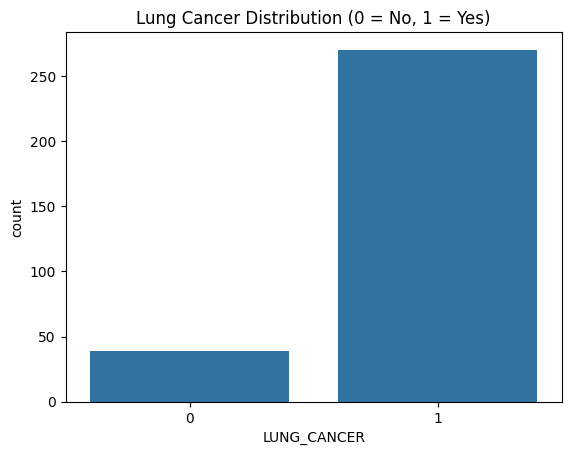

In [8]:
# Target distribution

sns.countplot(x="LUNG_CANCER", data=df)
plt.title("Lung Cancer Distribution (0 = No, 1 = Yes)")
plt.show()

In [9]:
df["LUNG_CANCER"].value_counts()

,count
LUNG_CANCER,
1,270
0,39


In [10]:
df["LUNG_CANCER"].value_counts(normalize=True)

,proportion
LUNG_CANCER,
1,0.873786
0,0.126214


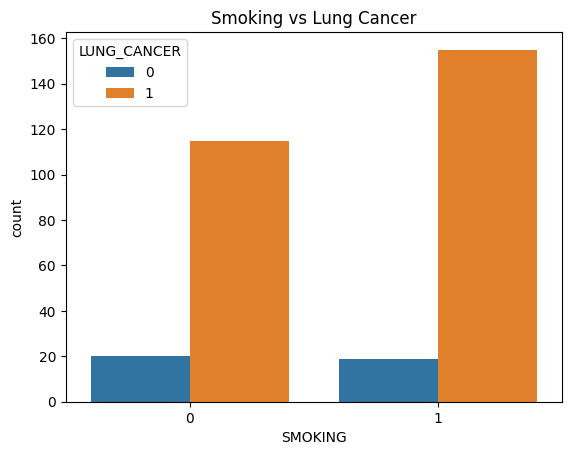

In [11]:
# Smoking vs Lung Cancer

sns.countplot(x="SMOKING", hue="LUNG_CANCER", data=df)
plt.title("Smoking vs Lung Cancer")
plt.show()

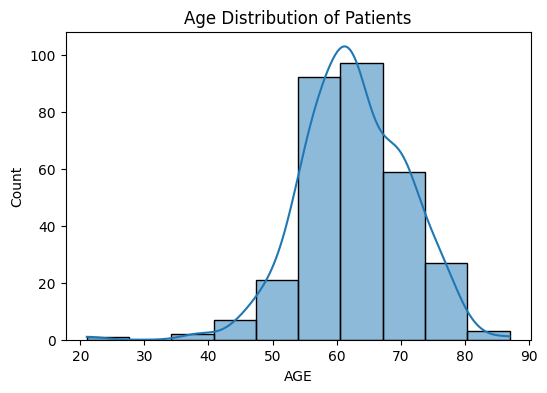

In [12]:
# Age distribution

plt.figure(figsize=(6,4))
sns.histplot(df["AGE"], bins=10, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

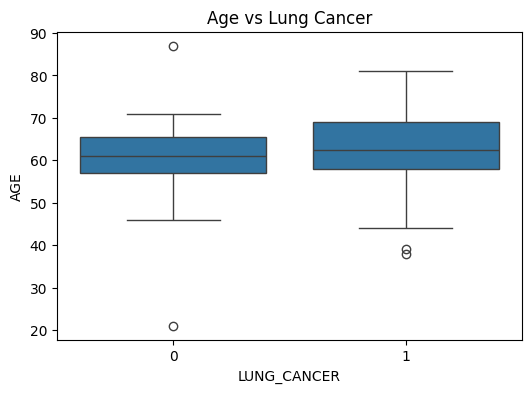

In [13]:
# Age vs Lung Cancer

plt.figure(figsize=(6,4))
sns.boxplot(x="LUNG_CANCER", y="AGE", data=df)
plt.title("Age vs Lung Cancer")
plt.show()

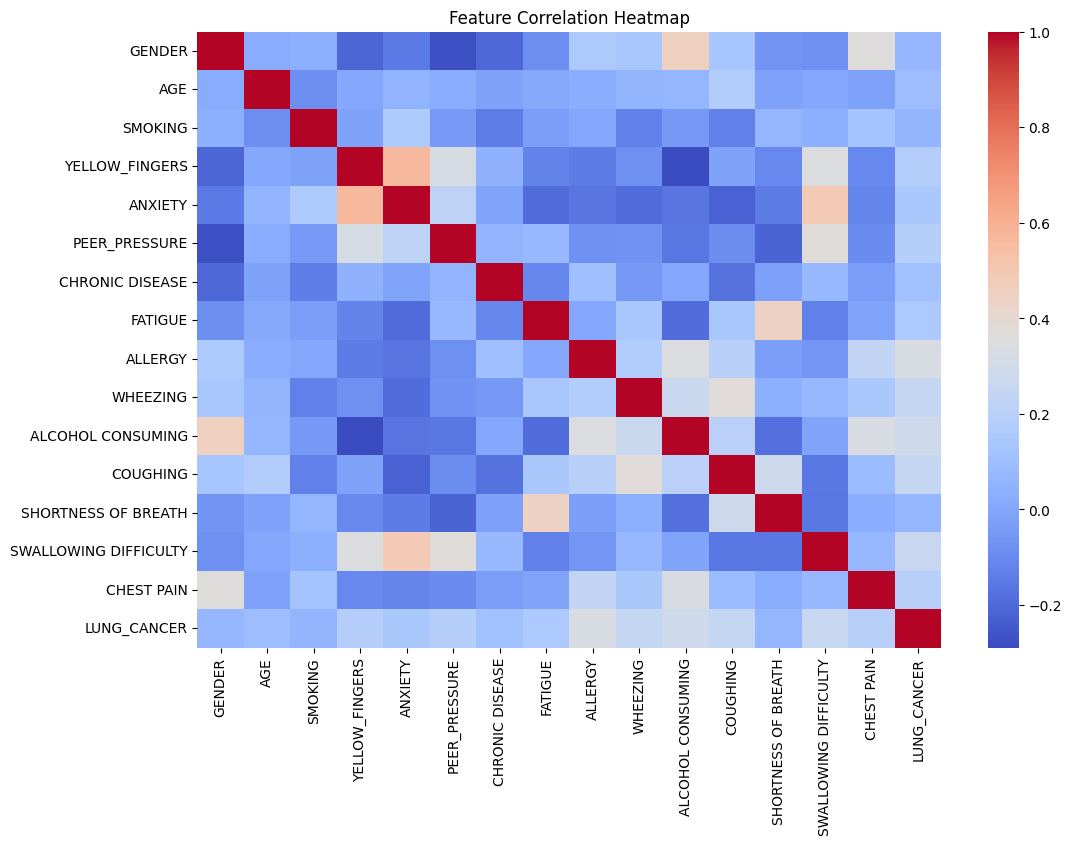

In [14]:
# Feature correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

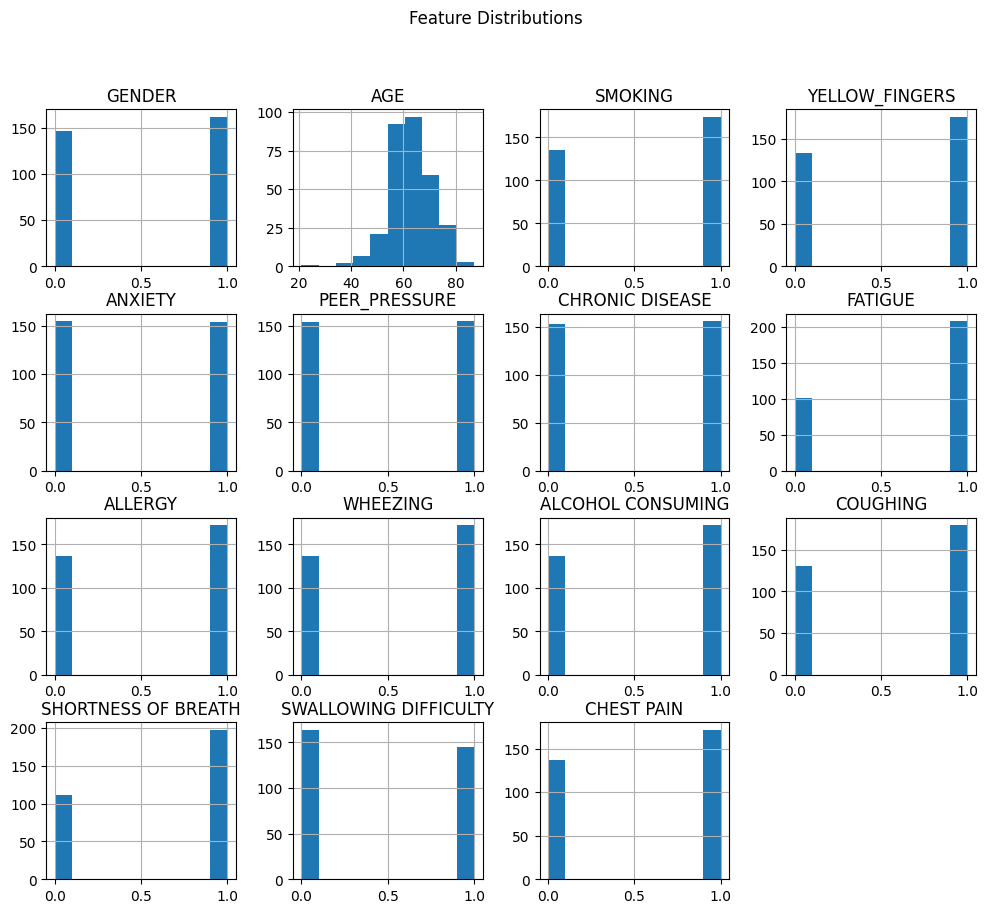

In [15]:
# Feature distribution

df.drop("LUNG_CANCER", axis=1).hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

**TRAIN / TEST SPLIT**

In [17]:
# Dataset split (80/20 for train/test):
# Stratified split used to preserve class distribution to ensure balanced representation of lung cancer cases in both sets

X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
df["LUNG_CANCER"].value_counts(normalize=False)

,count
LUNG_CANCER,
1,270
0,39


In [19]:
df["LUNG_CANCER"].value_counts(normalize=True)

,proportion
LUNG_CANCER,
1,0.873786
0,0.126214


In [20]:
y_train.value_counts(normalize=False)

,count
LUNG_CANCER,
1,216
0,31


In [21]:
y_train.value_counts(normalize=True)

,proportion
LUNG_CANCER,
1,0.874494
0,0.125506


In [22]:
# Apply SMOTE (Synthetic Minority Over-sampling Technique) to the training dataset:
# generates artificial minority-class samples (No Cancer) by interpolating between existing minority-class observations.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [23]:
# Train data counts after SMOTE

y_train_smote.value_counts(normalize=False)

,count
LUNG_CANCER,
1,216
0,216


In [24]:
# Train data proportion after SMOTE

y_train_smote.value_counts(normalize=True)

,proportion
LUNG_CANCER,
1,0.5
0,0.5


* The test set was left unchanged to ensure unbiased model evaluation.

In [25]:
y_test.value_counts(normalize=False)

,count
LUNG_CANCER,
1,54
0,8


In [26]:
y_test.value_counts(normalize=True)

,proportion
LUNG_CANCER,
1,0.870968
0,0.129032


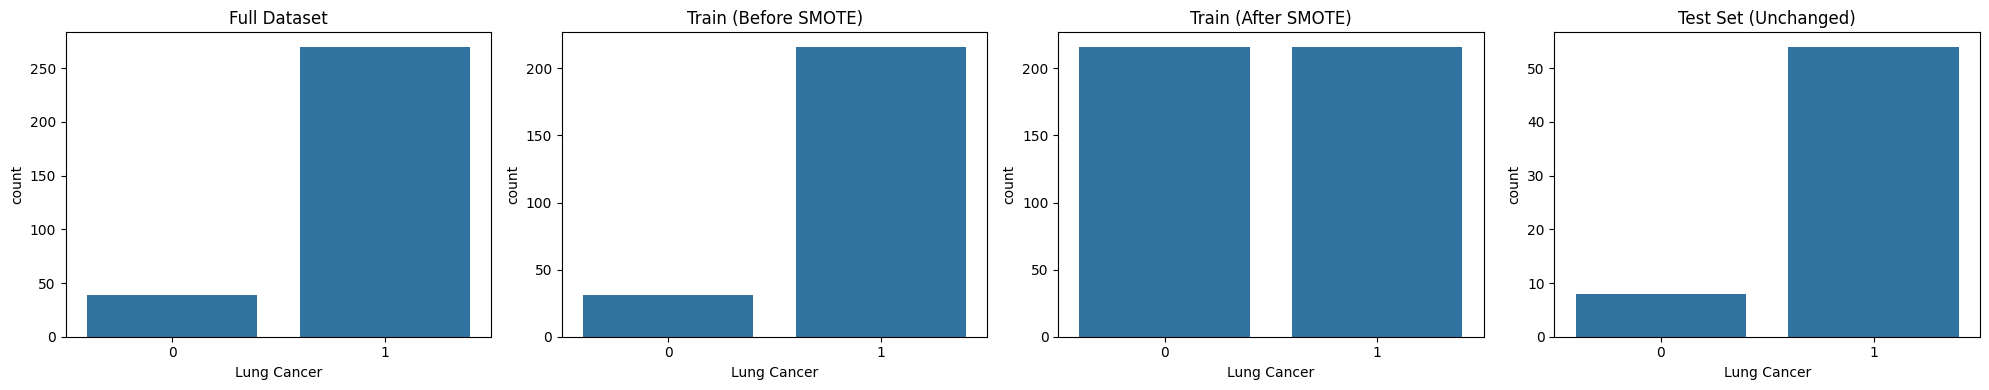

In [37]:
# Distribution comparison of full / train (before and after SMOTE) / test datasets

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

sns.countplot(x=df["LUNG_CANCER"], ax=axes[0])
axes[0].set_title("Full Dataset")
axes[0].set_xlabel("Lung Cancer")

sns.countplot(x=y_train, ax=axes[1])
axes[1].set_title("Train (Before SMOTE)")
axes[1].set_xlabel("Lung Cancer")

sns.countplot(x=y_train_smote, ax=axes[2])
axes[2].set_title("Train (After SMOTE)")
axes[2].set_xlabel("Lung Cancer")

sns.countplot(x=y_test, ax=axes[3])
axes[3].set_title("Test Set (Unchanged)")
axes[3].set_xlabel("Lung Cancer")

plt.tight_layout()
plt.show()

**MODEL COMPARISON**

Logistic regression   vs  Decision Tree  vs  Random forest  vs  Gradient boosting.

Model training was performed using the train_smote data.

In [27]:
# MODEL TRAINING AND PERFORMANCE EVALUATION

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))


# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))


# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.93      0.96      0.95        54

    accuracy                           0.90        62
   macro avg       0.80      0.73      0.76        62
weighted avg       0.89      0.90      0.90        62

Decision Tree
              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.96      0.91      0.93        54

    accuracy                           0.89        62
   macro avg       0.75      0.83      0.78        62
weighted avg       0.91      0.89      0.89        62

Random Forest
              precision    recall  f1-score   support

           0       0.58      0.88      0.70         8
           1       0.98      0.91      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.89      0.82        62
weighted avg       0.93   

In [28]:
# Accuracy summary

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.903226
1,Decision Tree,0.887097
2,Random Forest,0.903226
3,Gradient Boosting,0.838710


**CONFUSION MATRICES**

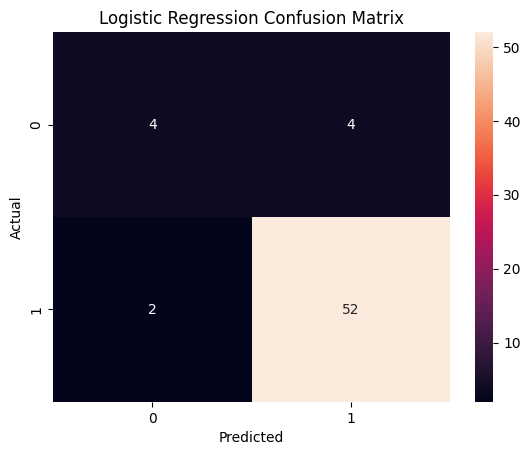

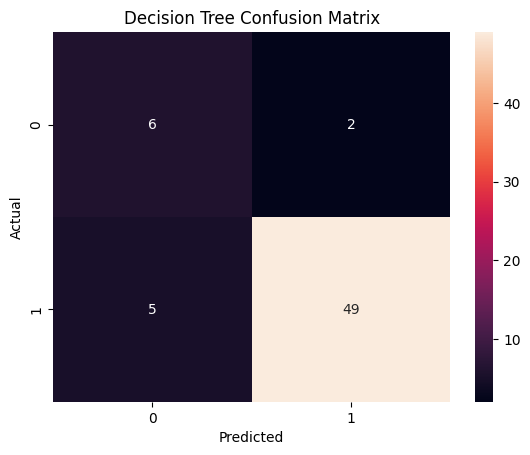

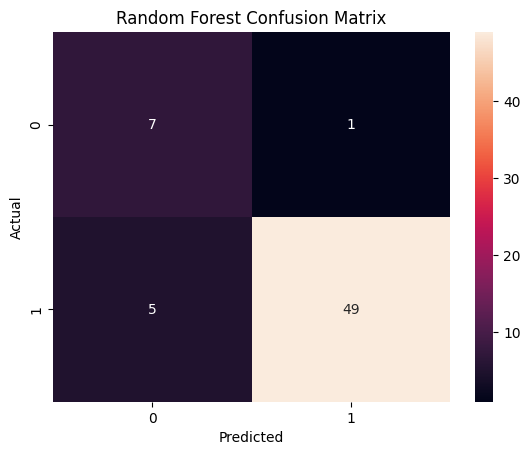

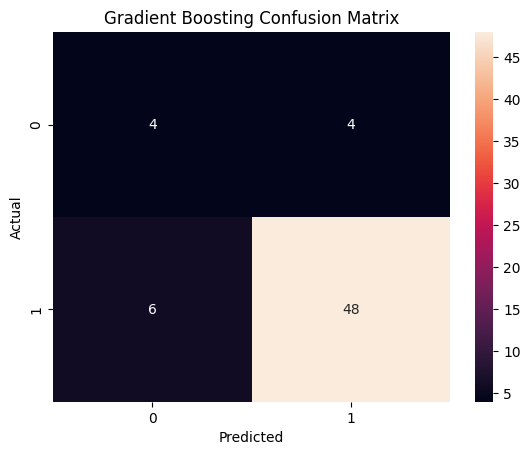

In [29]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure()
sns.heatmap(cm_gb, annot=True, fmt="d")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**FEATURE IMPORTANCE ANALYSIS**

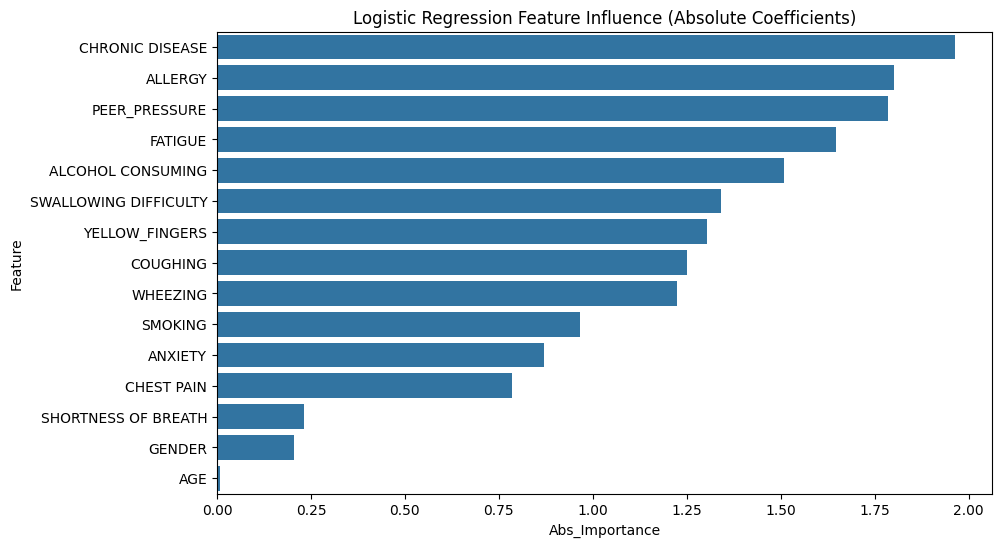

,Feature,Importance,Abs_Importance
6,CHRONIC DISEASE,1.964195,1.964195
8,ALLERGY,1.801633,1.801633
5,PEER_PRESSURE,1.784938,1.784938
7,FATIGUE,1.646779,1.646779
10,ALCOHOL CONSUMING,1.508989,1.508989
13,SWALLOWING DIFFICULTY,1.341701,1.341701
3,YELLOW_FINGERS,1.303659,1.303659
11,COUGHING,1.251027,1.251027
9,WHEEZING,1.223173,1.223173
2,SMOKING,0.966412,0.966412


In [30]:
# Logistic Regression
lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

lr_importance["Abs_Importance"] = np.abs(lr_importance["Coefficient"])

lr_importance = lr_importance.sort_values(by="Abs_Importance", ascending=False)
lr_importance

plt.figure(figsize=(10,6))
sns.barplot(data=lr_importance, x="Abs_Importance", y="Feature")
plt.title("Logistic Regression Feature Influence (Absolute Coefficients)")
plt.show()

lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lr.coef_[0]
})

lr_importance["Abs_Importance"] = np.abs(lr_importance["Importance"])

lr_importance = lr_importance.sort_values(by="Abs_Importance", ascending=False)

lr_importance

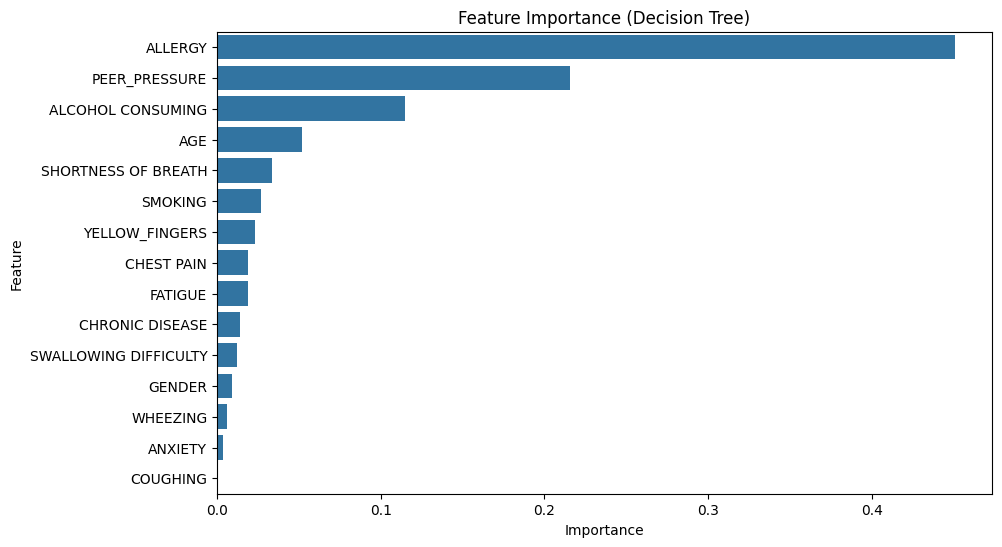

,Feature,Importance
8,ALLERGY,0.451015
5,PEER_PRESSURE,0.215817
10,ALCOHOL CONSUMING,0.114621
1,AGE,0.051946
12,SHORTNESS OF BREATH,0.033593
2,SMOKING,0.026746
3,YELLOW_FINGERS,0.022991
14,CHEST PAIN,0.019163
7,FATIGUE,0.018751
6,CHRONIC DISEASE,0.013832


In [31]:
# Decision Tree
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=dt_importance, x="Importance", y="Feature")
plt.title("Feature Importance (Decision Tree)")
plt.show()

dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

dt_importance = dt_importance.sort_values(by="Importance", ascending=False)

dt_importance

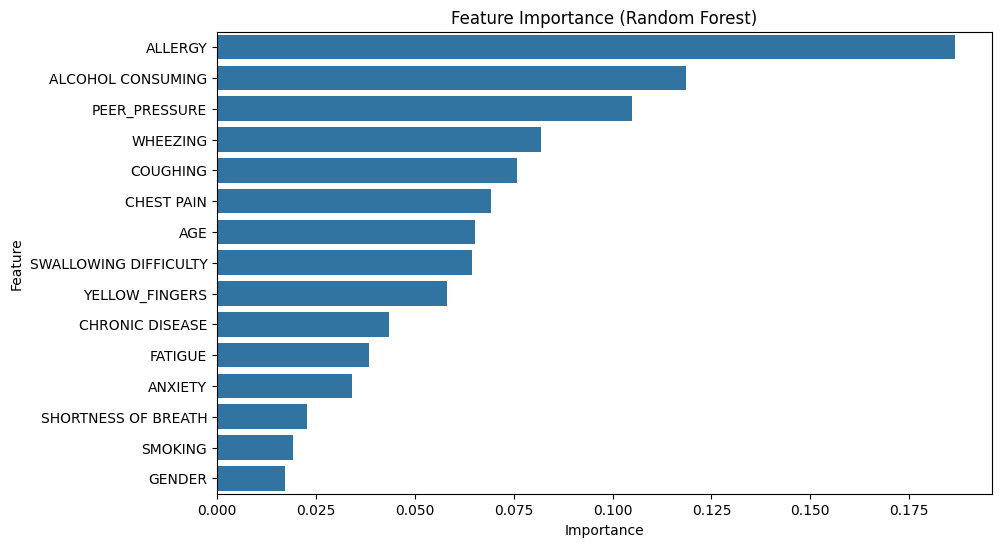

,Feature,Importance
8,ALLERGY,0.186609
10,ALCOHOL CONSUMING,0.118660
5,PEER_PRESSURE,0.104936
9,WHEEZING,0.081878
11,COUGHING,0.075916
14,CHEST PAIN,0.069386
1,AGE,0.065112
13,SWALLOWING DIFFICULTY,0.064471
3,YELLOW_FINGERS,0.058130
6,CHRONIC DISEASE,0.043392


In [32]:
# Random Forest
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance (Random Forest)")
plt.show()

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance

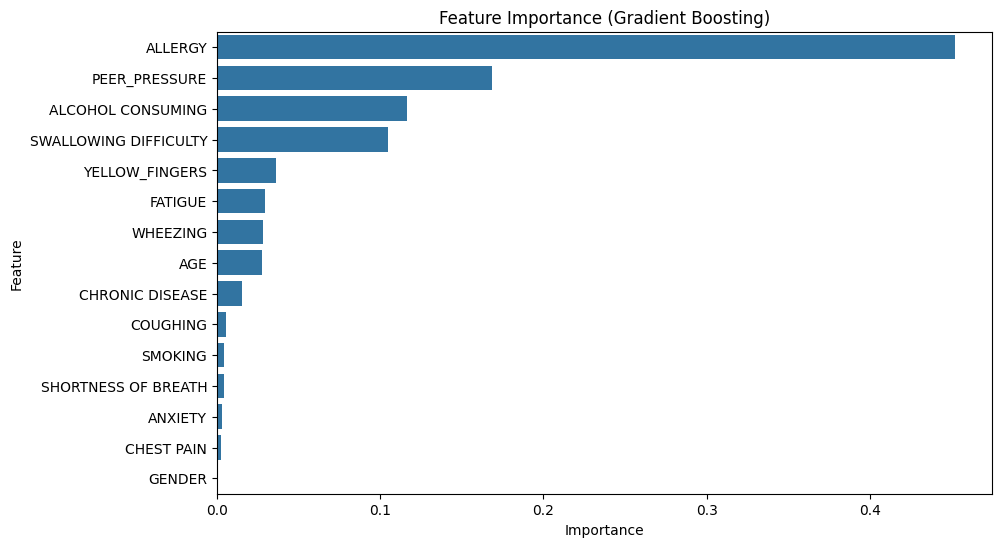

,Feature,Importance
8,ALLERGY,0.452244
5,PEER_PRESSURE,0.168426
10,ALCOHOL CONSUMING,0.116673
13,SWALLOWING DIFFICULTY,0.104976
3,YELLOW_FINGERS,0.036329
7,FATIGUE,0.029678
9,WHEEZING,0.028120
1,AGE,0.027519
6,CHRONIC DISEASE,0.015522
11,COUGHING,0.005727


In [33]:
# Gradient Boosting
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=gb_importance, x="Importance", y="Feature")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

gb_importance = gb_importance.sort_values(by="Importance", ascending=False)

gb_importance

**TRAIN VS TEST ACCURACY ANALYSIS**

In [34]:
# Evaluation of model generalization: training vs test accuracy.

train_acc_lr = accuracy_score(y_train_smote, lr.predict(X_train_smote))
test_acc_lr = accuracy_score(y_test, y_pred_lr)

train_acc_dt = accuracy_score(y_train_smote, dt.predict(X_train_smote))
test_acc_dt = accuracy_score(y_test, y_pred_dt)

train_acc_rf = accuracy_score(y_train_smote, rf.predict(X_train_smote))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

train_acc_gb = accuracy_score(y_train_smote, gb.predict(X_train_smote))
test_acc_gb = accuracy_score(y_test, y_pred_gb)

acc_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train Accuracy": [
        train_acc_lr,
        train_acc_dt,
        train_acc_rf,
        train_acc_gb
    ],
    "Test Accuracy": [
        test_acc_lr,
        test_acc_dt,
        test_acc_rf,
        test_acc_gb
    ]
})

acc_df

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.967593,0.903226
1,Decision Tree,1.000000,0.887097
2,Random Forest,1.000000,0.903226
3,Gradient Boosting,0.993056,0.838710


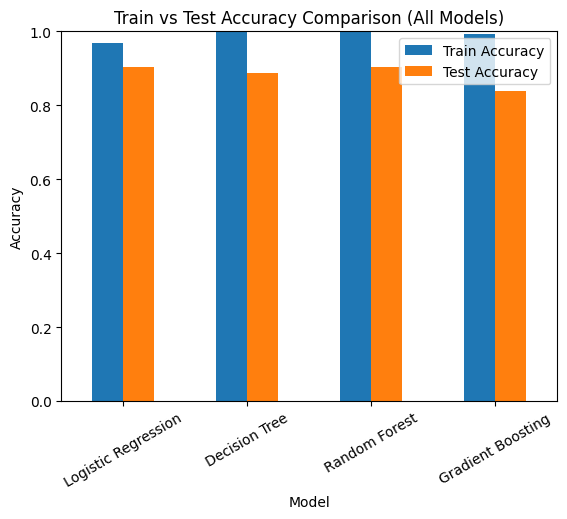

In [35]:
acc_df.set_index("Model").plot(kind="bar")
plt.title("Train vs Test Accuracy Comparison (All Models)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

**DISCUSSION AND CONCLUSION**

This project explored the use of machine learning models to predict lung cancer risk using demographic, lifestyle, and symptom-related features from a public Kaggle dataset. After cleaning the data, converting all variables to numerical format, and exploring its distribution, 4 machine learning models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

Because the dataset was highly imbalanced (87.4% lung cancer cases versus 12.6% non-cancer cases), the Synthetic Minority Oversampling Technique (SMOTE) was applied to the training set to generate artificial non-cancer samples and improve class balance. The test set was left unchanged to ensure unbiased model evaluation.

Logistic Regression and Random Forest achieved the highest test accuracy (~0.90), while Decision Tree showed a slight decrease in performance and Gradient Boosting achieved the lowest test accuracy. Logistic Regression demonstrated the most stable generalization performance, with very similar training and test accuracies, whereas Decision Tree and Random Forest achieved perfect training accuracy, which might indicate some degree of overfitting.

Feature importance analysis consistently showed that smoking was not the strongest predictor of lung cancer risk in this dataset. Allergy emerged as the most influential feature in the Decision Tree, Random Forest, and Gradient Boosting models, while Chronic Disease was the top predictor in Logistic Regression, with Allergy ranking second. Additionally, Alcohol Consuming and Peer Pressure were consistently among the most important features across the evaluated models, contributing significantly to the predictions.

After applying SMOTE to balance the training data, Logistic Regression and Random Forest achieved identical test accuracy (0.903). However, Logistic Regression showed less evidence of overfitting, with a smaller difference between training and test performance, indicating better generalization to unseen data. In addition, Logistic Regression is a simpler and more interpretable model, making its predictions easier to understand and explain in a medical context. Although Random Forest remains a strong performer and provides valuable insights through feature importance analysis, the results obtained in this study do not clearly demonstrate superior predictive performance compared to Logistic Regression. Therefore, Logistic Regression may be considered the preferred model for this dataset due to its comparable accuracy, better generalization behavior, and greater interpretability.

